In [1]:
import csv

with open("processed-actual-outages.csv") as file:
    csv_reader = csv.DictReader(file)
    actual_data = list(csv_reader)

In [2]:
from datetime import datetime

from tqdm import tqdm

date_keys = ["OutDatetime", "MinTimeStamp", "MaxTimeStamp"]

for row in tqdm(actual_data):
    row["PTID"] = int(row["PTID"])
    row["Voltage"] = int(row["Voltage"])
    for key in date_keys:
        row[key] = datetime.strptime(row[key], "%Y-%m-%d %H:%M:%S")

actual_data[0]

100%|██████████| 74063/74063 [00:01<00:00, 58066.83it/s]


{'PTID': 26053,
 'Name': 'MOUNTAIN-SWANROAD_115_104-3',
 'OutDatetime': datetime.datetime(2005, 1, 1, 0, 0),
 'MinTimeStamp': datetime.datetime(2012, 9, 11, 11, 52, 17),
 'MaxTimeStamp': datetime.datetime(2013, 8, 8, 8, 37, 17),
 'Voltage': 115,
 'FirstBus': 'MOUNTAIN',
 'SecondBus': 'SWANROAD',
 'OutageType': 'Planned'}

In [3]:
from pathlib import Path

output_path = Path("output")
output_path.mkdir(exist_ok=True)

# Dropped periods

In [4]:
from datetime import timedelta

# set current time as the day for the first row
current_date = datetime(2005, 1, 1)
end_date = datetime(2026, 3, 1)
day_timedelta = timedelta(days=1)
no_event_dates = []
while current_date < end_date:
    records = [
        row
        for row in actual_data
        if current_date <= row["OutDatetime"] < current_date + day_timedelta
    ]
    if len(records) == 0:
        no_event_dates.append(current_date.strftime("%Y-%m-%d"))
    current_date += day_timedelta

(output_path / "no_event_dates.txt").write_text("\n".join(no_event_dates))

8711

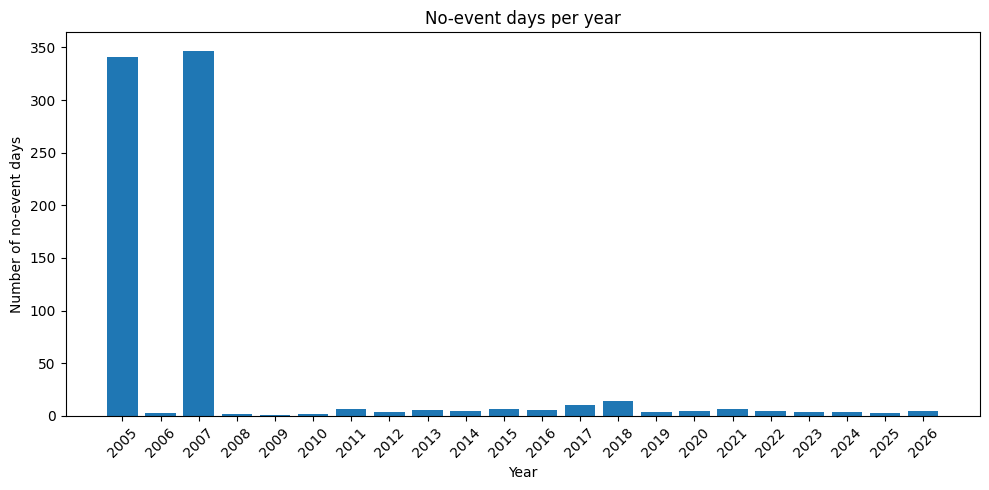

In [5]:
from collections import Counter

import matplotlib.pyplot as plt

# count no-event days per year (no_event_dates is defined in the notebook)
years = [int(d.split("-")[0]) for d in no_event_dates]
counts = Counter(years)
years, counts = list(zip(*sorted(counts.items(), key=lambda x: x[0])))


fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(y) for y in years], counts)
ax.set_xlabel("Year")
ax.set_ylabel("Number of no-event days")
ax.set_title("No-event days per year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "no_event_days_per_year.pdf", dpi=300)

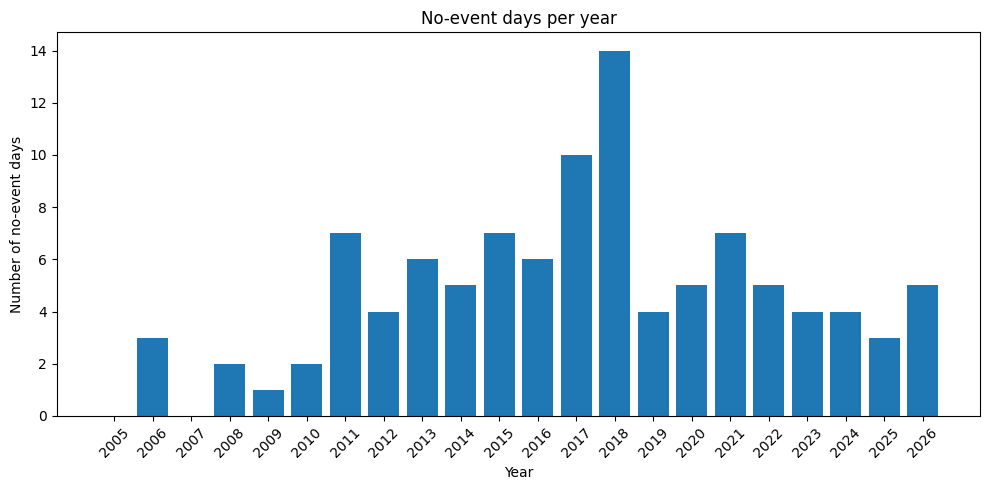

In [6]:
counts = list(counts)
counts[0] = 0
counts[2] = 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(y) for y in years], counts)
ax.set_xlabel("Year")
ax.set_ylabel("Number of no-event days")
ax.set_title("No-event days per year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "no_event_days_per_year-nooutlier.pdf", dpi=300)

# Basic countings

In [7]:
import igraph

our_bus_set = set(
    [row[key] for row in actual_data for key in ["FirstBus", "SecondBus"]]
)

print(f"num vertices: {len(our_bus_set)}")

bus_name_to_index = {
    bus_name: i for i, bus_name in enumerate(sorted(list(our_bus_set)))
}
index_to_bus_name = {
    i: bus_name for i, bus_name in enumerate(sorted(list(our_bus_set)))
}
n = len(bus_name_to_index)
g = igraph.Graph(n=len(bus_name_to_index), directed=False)

edge_set = set()
for datum in actual_data:
    b1, b2 = datum["FirstBus"], datum["SecondBus"]
    b1_index, b2_index = bus_name_to_index[b1], bus_name_to_index[b2]
    edge_set.add((b1_index, b2_index))
g.add_edges(list(edge_set))

print(g.is_connected())

num vertices: 1376
True


In [8]:
ref_time = datetime(2008, 1, 1)
len(actual_data), len([row for row in actual_data if ref_time <= row["OutDatetime"]])

(74063, 70079)

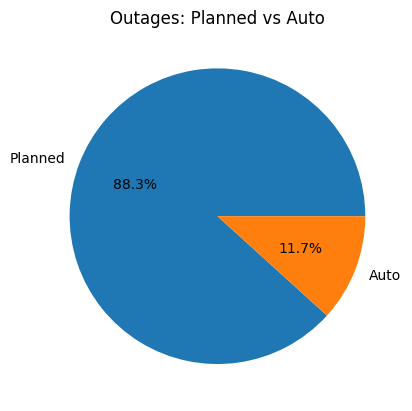

In [9]:
n = len(actual_data)
n_planned = len([row for row in actual_data if row["OutageType"] == "Planned"])
n_auto = len([row for row in actual_data if row["OutageType"] == "Auto"])

fig, ax = plt.subplots()
ax.pie([n_planned, n_auto], labels=["Planned", "Auto"], autopct="%1.1f%%")
ax.set_title("Outages: Planned vs Auto")

plt.savefig(output_path / "planned_vs_auto.pdf", dpi=300)

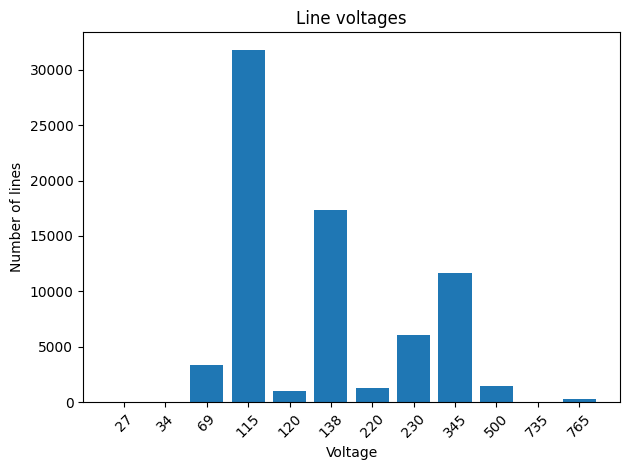

In [10]:
counts = Counter([row["Voltage"] for row in actual_data])
voltages, counts = list(zip(*sorted(counts.items(), key=lambda x: x[0])))

fig, ax = plt.subplots()
ax.bar([str(y) for y in voltages], counts)
ax.set_xlabel("Voltage")
ax.set_ylabel("Number of lines")
ax.set_title("Line voltages")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "voltages.pdf", dpi=300)

### Line outage frequency histogram

In [11]:
counts = Counter([row["PTID"] for row in actual_data])
freqs = list(counts.values())

MAX = 200
ax.hist([min(f, MAX) for f in freqs], bins=MAX + 1)
ax.set_xlabel("Number of outages (per line)")
ax.set_ylabel("Number of lines")
ax.set_title("Line outage frequency histogram")
plt.tight_layout()
plt.savefig(output_path / "line_outage_frequency_histogram.pdf", dpi=300)

<Figure size 640x480 with 0 Axes>

# Form failure scenarios

In [12]:
actual_data_auto = [row for row in actual_data if row["OutageType"] == "Auto"]
actual_data_planned = [row for row in actual_data if row["OutageType"] == "Planned"]

In [13]:
# Form cascading failures based on time thresholds
# TIME THRESHOLDS (in seconds)
SAME_GENERATION_THRESHOLD = 60 * 1
SAME_CASCADING_THRESHOLD = 3600

cascading_failures = []
current_cascade = [[actual_data[0]]]
for datum in actual_data[1:]:
    last_out_datetime = current_cascade[-1][-1]["OutDatetime"]
    current_out_datetime = datum["OutDatetime"]
    time_diff = (current_out_datetime - last_out_datetime).total_seconds()
    if time_diff <= SAME_GENERATION_THRESHOLD:
        current_cascade[-1].append(datum)
        continue
    if time_diff <= SAME_CASCADING_THRESHOLD:
        current_cascade.append([datum])
        continue
    if time_diff > SAME_CASCADING_THRESHOLD:
        cascading_failures.append(current_cascade)
        current_cascade = [[datum]]
        continue
len(cascading_failures)

31611

In [14]:
generation_sizes = [len(cascading_failure) for cascading_failure in cascading_failures]
cascading_failure_sizes = [
    sum(len(gen) for gen in cascading_failure)
    for cascading_failure in cascading_failures
]
initial_failure_sizes = [
    len(cascading_failure[0]) for cascading_failure in cascading_failures
]

In [15]:
len(cascading_failures)

31611

In [16]:
from typing import Optional

import numpy as np
import powerlaw


def plot_log_log(
    size_list: list[int],
    xmin: Optional[int] = None,
    xmax: Optional[int] = None,
    dpi: Optional[int] = 100,
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")
    # ax.set_xlim(1, 50)

    # fit a line
    fit = powerlaw.Fit(
        size_list,
        discrete=True,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_pdf(ax=ax, linestyle="--", label="Power-law fit")

    return ax

alpha: 2.8329344453459084
xmin : 3.0


<Axes: >

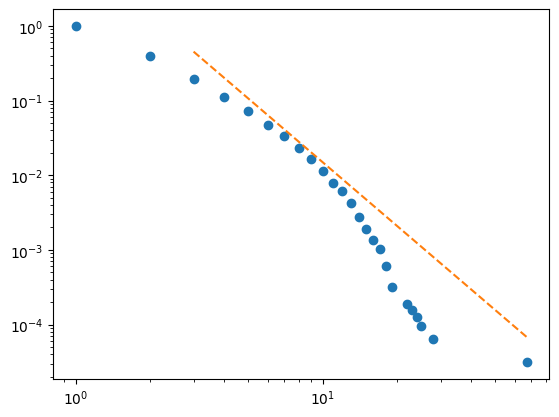

In [17]:
plot_log_log(generation_sizes)

alpha: 1.9311210987220218
xmin : 1.0


<Axes: >

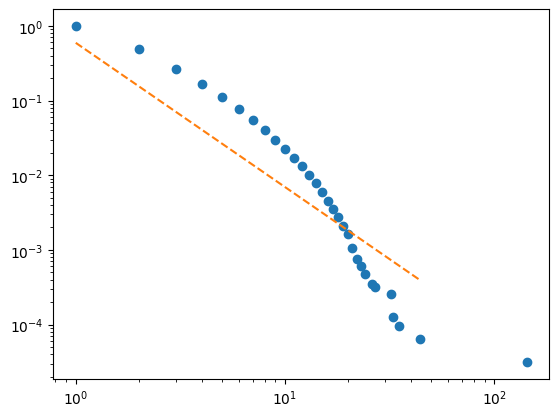

In [18]:
plot_log_log(cascading_failure_sizes, xmin=1, xmax=50)

# Rebound

In [19]:
cascading_failures[0]

[[{'PTID': 26053,
   'Name': 'MOUNTAIN-SWANROAD_115_104-3',
   'OutDatetime': datetime.datetime(2005, 1, 1, 0, 0),
   'MinTimeStamp': datetime.datetime(2012, 9, 11, 11, 52, 17),
   'MaxTimeStamp': datetime.datetime(2013, 8, 8, 8, 37, 17),
   'Voltage': 115,
   'FirstBus': 'MOUNTAIN',
   'SecondBus': 'SWANROAD',
   'OutageType': 'Planned'}]]

In [38]:
for scenario in cascading_failures:
    if len(scenario) > 20 and scenario[0][0]["OutDatetime"].year > 2007:
        break
print(len(scenario), scenario)

28 [[{'PTID': 101015041, 'Name': 'BARBOURH-MEEK.JCT_345_395-1', 'OutDatetime': datetime.datetime(2011, 3, 28, 6, 30), 'MinTimeStamp': datetime.datetime(2011, 3, 28, 10, 57, 19), 'MaxTimeStamp': datetime.datetime(2011, 3, 28, 23, 57, 21), 'Voltage': 345, 'FirstBus': 'BARBOURH', 'SecondBus': 'MEEK.JCT', 'OutageType': 'Auto'}], [{'PTID': 25900, 'Name': 'MNCHESTR-MEEK.JCT_345_395-3', 'OutDatetime': datetime.datetime(2011, 3, 28, 6, 32), 'MinTimeStamp': datetime.datetime(2011, 3, 28, 6, 37, 18), 'MaxTimeStamp': datetime.datetime(2011, 3, 28, 23, 57, 21), 'Voltage': 345, 'FirstBus': 'MNCHESTR', 'SecondBus': 'MEEK.JCT', 'OutageType': 'Planned'}], [{'PTID': 325648, 'Name': 'REYNOLDS-RVSD_TAP_115_4', 'OutDatetime': datetime.datetime(2011, 3, 28, 6, 44), 'MinTimeStamp': datetime.datetime(2011, 3, 28, 6, 47, 18), 'MaxTimeStamp': datetime.datetime(2011, 3, 31, 23, 57, 22), 'Voltage': 115, 'FirstBus': 'REYNOLDS', 'SecondBus': 'RVSD_TAP', 'OutageType': 'Planned'}], [{'PTID': 25377, 'Name': 'CHATGUAY

In [ ]:
def is_active(row, dt):
    if row["OutDatetime"] <= dt <= row["MaxTimeStamp"]:
        return False
    return True


time_resolution = timedelta(hours=1)
min_time = min([row["OutDatetime"] for gen in scenario for row in gen]) - timedelta(
    days=1
)
max_time = min([row["MaxTimeStamp"] for gen in scenario for row in gen]) + timedelta(
    days=30
)
voltage_sum = sum([row["Voltage"] for gen in scenario for row in gen])

flat_scenario = sum(scenario, [])
t_list, v_list = [int(min_time.timestamp())], [voltage_sum]
current_time = min_time
while current_time < max_time:
    current_time += time_resolution
    current_voltage = sum(
        [row["Voltage"] for row in flat_scenario if is_active(row, current_time)]
    )
    t_list.append(int(current_time.timestamp()))
    v_list.append(current_voltage)

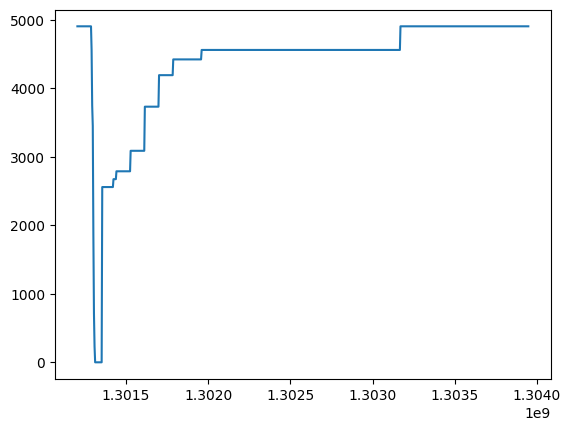

In [53]:
plt.plot(t_list, v_list)